### Importing libraries 

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import psycopg2
import numpy as np
from sqlalchemy import create_engine, text
import itertools
from PIL import Image


### Defining a user defined class to raise custom exceptions 

In [2]:
class UserDefinedException(Exception):
    pass

### Defining methods to create DB Connection and DB engine  

In [3]:
def get_connection(user, password, host, port, database):
    return create_engine(
        url="postgresql://{0}:{1}@{2}:{3}/{4}".format(
            user, password, host, port, database
        )
    )

In [4]:
def get_engine(db_user , password , db_name , db_host = "localhost" , port = "5432"):
    try:
        engine = None
        engine = get_connection (db_user, password, db_host, port, db_name) 
        engine = engine.connect()
        return engine
    except Exception as e:
        print(f"Failed while connnecting to DB {e}")

In [5]:
db_engine = get_engine(db_user = "postgres" , password = "welcome" ,db_name = "postgres")

In [6]:
try :
    if db_engine:
        print("DB engine is active..Proceeding further")
    else : raise UserDefinedException ("DB inactive, aborting process")
except UserDefinedException as e:
    print(e)

DB engine is active..Proceeding further


### Retriving said data from the table

In [7]:
def get_data_from_database(query, engine):
    try:
        data = pd.read_sql(text(query) , con = engine)
        if data.empty:
            raise UserDefinedException("Data Not available")
        return data
    except UserDefinedException as e:
        print(e)
    except Exception as e:
        print(e)
    

### Fetching data from Player , Country and Batting stats Table 

In [8]:
player_data = get_data_from_database("select * from players;" , db_engine)
country_data = get_data_from_database("select * from country;" , db_engine)
batting_data = get_data_from_database("select * from batting_stats;" , db_engine)

In [9]:
player_data.head()

,id,name,gender,bating_style,bowling_style,playing_role,country_id
0,1346729,Dilara Akter,Female,right-hand bat,,wicketkeeper batter,25
1,627048,Fahima Khatun,Female,right-hand bat,legbreak,bowler,25
2,1195124,Fariha Trisna,Female,right-hand bat,left-arm medium,bowler,25
3,343649,Jahanara Alam,Female,right-hand bat,right-arm medium,bowler,25
4,346295,Lata Mondal,Female,right-hand bat,right-arm medium,allrounder,25


In [10]:
country_data.head()

,country_id,country_name
0,40,Afghanistan
1,2,Australia
2,25,Bangladesh
3,1,England
4,6,India


### Printing all tables data size 

In [11]:
print(f"Player data : {player_data.shape}")
print(f"Country data : {country_data.shape}")
print(f"Batting stats data : {batting_data.shape}")

Player data : (666, 7)
Country data : (12, 2)
Batting stats data : (931, 16)


### Replacing Battings stats DF columns 

In [12]:
replace_columns  = {'100s' : "centuries", '50': "half-century", '0s':"duck_out", '4s':"fours", '6s':"sixes"}
batting_data.rename(replace_columns , axis = 1 , inplace = True)
batting_data.head()

,id,span,matches,innings,not_out,runs,high_score,average_score,ball_faced,strike_rate,centuries,half-century,duck_out,fours,sixes,format
0,420402,2018-2021,5,8.0,1.0,172.0,48*,24.57,412.0,41.74,0.0,0.0,1.0,17.0,2.0,Test
1,921509,2019-2021,4,8.0,0.0,356.0,87,44.50,769.0,46.29,0.0,3.0,0.0,41.0,4.0,Test
2,440970,2018-2021,5,10.0,4.0,353.0,200*,58.83,803.0,43.96,1.0,1.0,0.0,43.0,1.0,Test
3,703323,2019-2019,3,6.0,1.0,110.0,65*,22.00,253.0,43.47,0.0,1.0,0.0,13.0,2.0,Test
4,25913,2018-2019,3,6.0,0.0,33.0,24,5.50,68.0,48.52,0.0,0.0,3.0,4.0,1.0,Test


###  Merging all three Data Frames into one Using inner join condition and displaying the data 

In [13]:
data = pd.merge(player_data, country_data, on='country_id', how='inner')
data = pd.merge(  data, batting_data, on='id', how='inner')

In [14]:
data.shape

(931, 23)

In [15]:
data.head(10)

,id,name,gender,bating_style,bowling_style,playing_role,country_id,country_name,span,matches,...,high_score,average_score,ball_faced,strike_rate,centuries,half-century,duck_out,fours,sixes,format
0,935995,Afif Hossain,Male,left-hand bat,right-arm offbreak,allrounder,25,Bangladesh,2020-2022,22,...,93*,35.35,546.0,90.65,0.0,3.0,2.0,45.0,7.0,ODI
1,935995,Afif Hossain,Male,left-hand bat,right-arm offbreak,allrounder,25,Bangladesh,2018-2022,60,...,77*,21.34,832.0,120.55,0.0,3.0,6.0,72.0,33.0,T20
2,380354,Anamul Haque,Male,right-hand bat,,wicketkeeper batter,25,Bangladesh,2013-2022,5,...,23,10.00,260.0,38.46,0.0,0.0,1.0,14.0,0.0,Test
3,380354,Anamul Haque,Male,right-hand bat,,wicketkeeper batter,25,Bangladesh,2012-2022,44,...,120,30.58,1691.0,74.15,3.0,5.0,6.0,122.0,27.0,ODI
4,380354,Anamul Haque,Male,right-hand bat,,wicketkeeper batter,25,Bangladesh,2012-2022,20,...,58,24.72,395.0,112.65,0.0,1.0,1.0,46.0,14.0,T20
5,932355,Ebadot Hossain,Male,right-hand bat,right-arm fast-medium,bowler,25,Bangladesh,2019-2022,18,...,21*,3.33,224.0,22.32,0.0,0.0,9.0,6.0,1.0,Test
6,932355,Ebadot Hossain,Male,right-hand bat,right-arm fast-medium,bowler,25,Bangladesh,2022-2022,4,...,0*,0.00,6.0,0.00,0.0,0.0,2.0,0.0,0.0,ODI
7,932355,Ebadot Hossain,Male,right-hand bat,right-arm fast-medium,bowler,25,Bangladesh,2022-2022,4,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,T20
8,926629,Hasan Mahmud,Male,right-hand bat,right-arm medium,bowler,25,Bangladesh,2021-2022,6,...,1,0.33,11.0,9.09,0.0,0.0,2.0,0.0,0.0,ODI
9,926629,Hasan Mahmud,Male,right-hand bat,right-arm medium,bowler,25,Bangladesh,2020-2022,10,...,3,2.50,10.0,50.00,0.0,0.0,1.0,0.0,0.0,T20


### Defining a method to define al the unwanted columns in the dataframe and removing colums 

In [16]:
def remove_unwanted_columns(unwanted_columns):
    for i in unwanted_columns:
        if i in data.columns:
            data.drop(i, axis = 1 , inplace = True)
    print(f"{unwanted_columns} removed from data frame")
    
unwanted_columns = ['id' , 'country_id','bowling_style' , 'playing_role' , 'span', 'high_score']
remove_unwanted_columns(unwanted_columns)

['id', 'country_id', 'bowling_style', 'playing_role', 'span', 'high_score'] removed from data frame


### Defining a method to show null values 

In [17]:
def return_null_value_summary(data):
    return data.isnull().sum().to_dict()
return_null_value_summary(data)

{'name': 0,
 'gender': 0,
 'bating_style': 0,
 'country_name': 0,
 'matches': 0,
 'innings': 18,
 'not_out': 18,
 'runs': 18,
 'average_score': 49,
 'ball_faced': 18,
 'strike_rate': 18,
 'centuries': 18,
 'half-century': 18,
 'duck_out': 18,
 'fours': 18,
 'sixes': 18,
 'format': 0}

### Dropping null values from a specified column 

In [18]:
data.dropna(subset = ['innings'] , inplace = True)

In [19]:
return_null_value_summary(data)

{'name': 0,
 'gender': 0,
 'bating_style': 0,
 'country_name': 0,
 'matches': 0,
 'innings': 0,
 'not_out': 0,
 'runs': 0,
 'average_score': 31,
 'ball_faced': 0,
 'strike_rate': 0,
 'centuries': 0,
 'half-century': 0,
 'duck_out': 0,
 'fours': 0,
 'sixes': 0,
 'format': 0}

### Defining a method to compute average score for missed data and conerting it into int 

In [20]:
def compute_avg_score(x):
    if  pd.isna(x['average_score']):
        active_innings = int(x['innings']  - x['not_out']) if int(x['innings']) != int(x['not_out']) else 1
        return round(x['runs'] / active_innings,2)
    else: return round(x['average_score'] ,2)
data['average_score'] = data[['innings' , 'not_out' , 'runs' , 'average_score']].apply(lambda x :
                                                            compute_avg_score(x) , axis =1)
        

In [21]:
return_null_value_summary(data)

{'name': 0,
 'gender': 0,
 'bating_style': 0,
 'country_name': 0,
 'matches': 0,
 'innings': 0,
 'not_out': 0,
 'runs': 0,
 'average_score': 0,
 'ball_faced': 0,
 'strike_rate': 0,
 'centuries': 0,
 'half-century': 0,
 'duck_out': 0,
 'fours': 0,
 'sixes': 0,
 'format': 0}

### Dropping duplicates data 

In [22]:
data.drop_duplicates()

,name,gender,bating_style,country_name,matches,innings,not_out,runs,average_score,ball_faced,strike_rate,centuries,half-century,duck_out,fours,sixes,format
0,Afif Hossain,Male,left-hand bat,Bangladesh,22,19.0,5.0,495.0,35.35,546.0,90.65,0.0,3.0,2.0,45.0,7.0,ODI
1,Afif Hossain,Male,left-hand bat,Bangladesh,60,55.0,8.0,1003.0,21.34,832.0,120.55,0.0,3.0,6.0,72.0,33.0,T20
2,Anamul Haque,Male,right-hand bat,Bangladesh,5,10.0,0.0,100.0,10.00,260.0,38.46,0.0,0.0,1.0,14.0,0.0,Test
3,Anamul Haque,Male,right-hand bat,Bangladesh,44,41.0,0.0,1254.0,30.58,1691.0,74.15,3.0,5.0,6.0,122.0,27.0,ODI
4,Anamul Haque,Male,right-hand bat,Bangladesh,20,20.0,2.0,445.0,24.72,395.0,112.65,0.0,1.0,1.0,46.0,14.0,T20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,Usman Ghani,Male,right-hand bat,Afghanistan,17,17.0,0.0,435.0,25.58,578.0,75.25,1.0,2.0,3.0,39.0,10.0,ODI
927,Usman Ghani,Male,right-hand bat,Afghanistan,33,32.0,3.0,764.0,26.34,707.0,108.06,0.0,4.0,0.0,74.0,21.0,T20
928,Yamin Ahmadzai,Male,right-hand bat,Afghanistan,5,9.0,0.0,32.0,3.55,91.0,35.16,0.0,0.0,3.0,3.0,2.0,Test
929,Yamin Ahmadzai,Male,right-hand bat,Afghanistan,9,5.0,2.0,9.0,3.00,32.0,28.12,0.0,0.0,1.0,0.0,0.0,ODI


### checking data types 

In [23]:
data.dtypes

name              object
gender            object
bating_style      object
country_name      object
matches            int64
innings          float64
not_out          float64
runs             float64
average_score    float64
ball_faced       float64
strike_rate      float64
centuries        float64
half-century     float64
duck_out         float64
fours            float64
sixes            float64
format            object
dtype: object

### converting data types 

In [24]:
for i in ['runs' , 'not_out','innings', 'centuries' , 'half-century' , 'duck_out' , 'fours' , 'sixes' ]:
    data[i] = data[i].astype(int)


In [25]:
data = data[data['innings']> 5]
data.head()

,name,gender,bating_style,country_name,matches,innings,not_out,runs,average_score,ball_faced,strike_rate,centuries,half-century,duck_out,fours,sixes,format
0,Afif Hossain,Male,left-hand bat,Bangladesh,22,19,5,495,35.35,546.0,90.65,0,3,2,45,7,ODI
1,Afif Hossain,Male,left-hand bat,Bangladesh,60,55,8,1003,21.34,832.0,120.55,0,3,6,72,33,T20
2,Anamul Haque,Male,right-hand bat,Bangladesh,5,10,0,100,10.00,260.0,38.46,0,0,1,14,0,Test
3,Anamul Haque,Male,right-hand bat,Bangladesh,44,41,0,1254,30.58,1691.0,74.15,3,5,6,122,27,ODI
4,Anamul Haque,Male,right-hand bat,Bangladesh,20,20,2,445,24.72,395.0,112.65,0,1,1,46,14,T20


### splitting data and creating new data frames for further usage 

In [26]:
name_groups = data.groupby(['name']) 
player_centuries = name_groups['centuries'].sum().reset_index()
player_half_centuries = name_groups['half-century'].sum().reset_index()
player_runs = name_groups['runs'].sum().reset_index()
test_data =data[data['format']=='Test']
odi_data=data[data['format']=='ODI']
t20_data =data[data['format']=='T20']

##### In the above cell , We have created 4 new data frames which will store the data based on used groups and format

### Plotting Top 5 run scorers from all countries

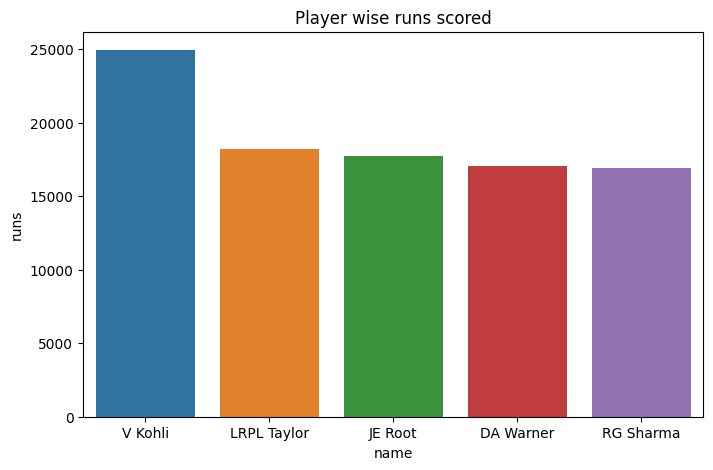

In [27]:
plt.subplots(figsize = ([8,5]))
player_runs = player_runs.nlargest(5, 'runs')
sns.barplot(x='name', y='runs', data=player_runs )
plt.title('Player wise runs scored')
plt.show()

##### From the above plot, we can identify the top 5 run scorers across all the formats, Virat Stood first with maximum runs followed by Taylor , Root , Warner , Sharma 

### Plotting top 5 player having most centuries and Half-centuries 

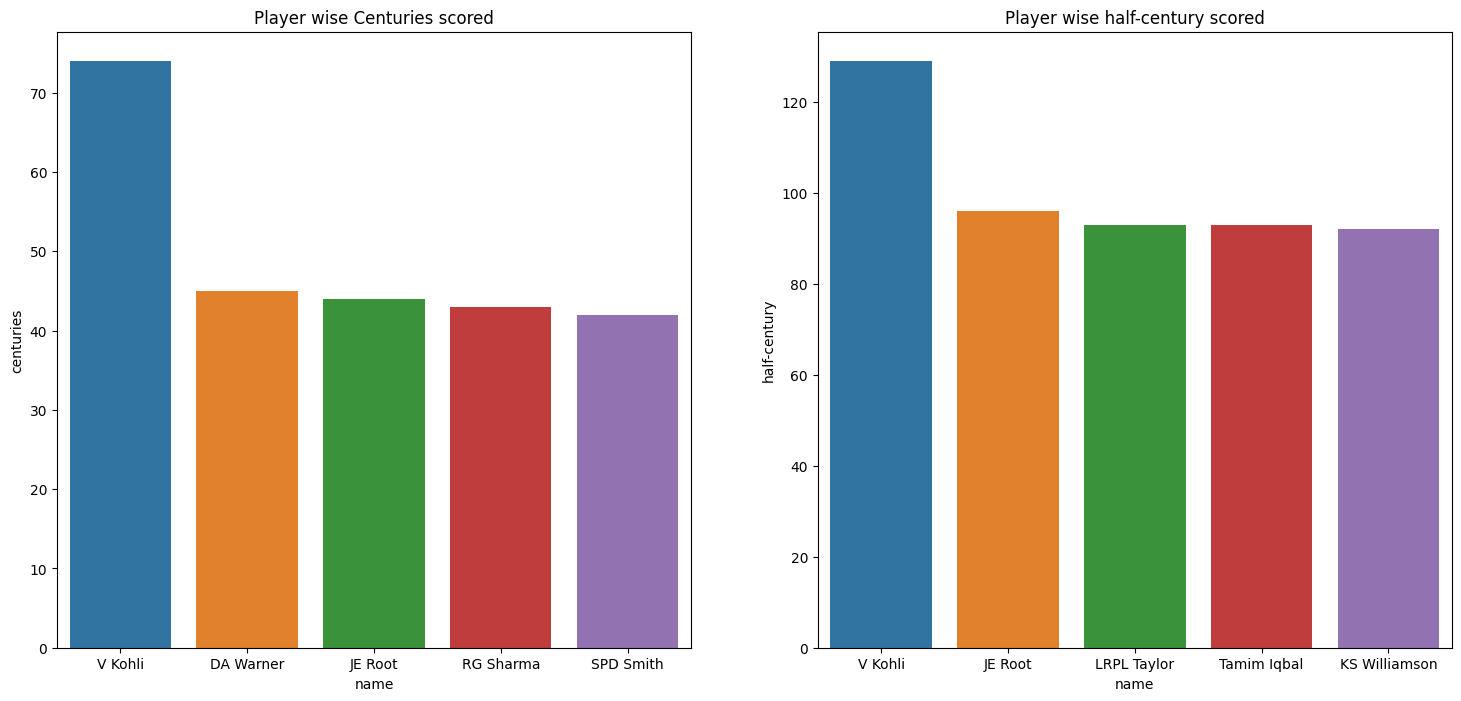

In [28]:

fig, (axis1, axis2) = plt.subplots(1,2, figsize=(18, 8))

player_centuries = player_centuries.nlargest(5, 'centuries')
player_half_centuries = player_half_centuries.nlargest(5, 'half-century')
sns.barplot(x='name', y='centuries', data=player_centuries , ax = axis1 )
sns.barplot(x='name', y='half-century', data=player_half_centuries ,ax = axis2)
axis1.set_title('Player wise Centuries scored')
axis2.set_title('Player wise half-century scored')
plt.show()

##### From the above plot, we can identify the top 5 players having most centuries and half-centuries across all the formats, Virat Stood first with maximum Centuries and half - centuries followed by warner and Root in centuries and Root , Taylor in half-centuries 

### Plotting top 5 players based on their Average score 

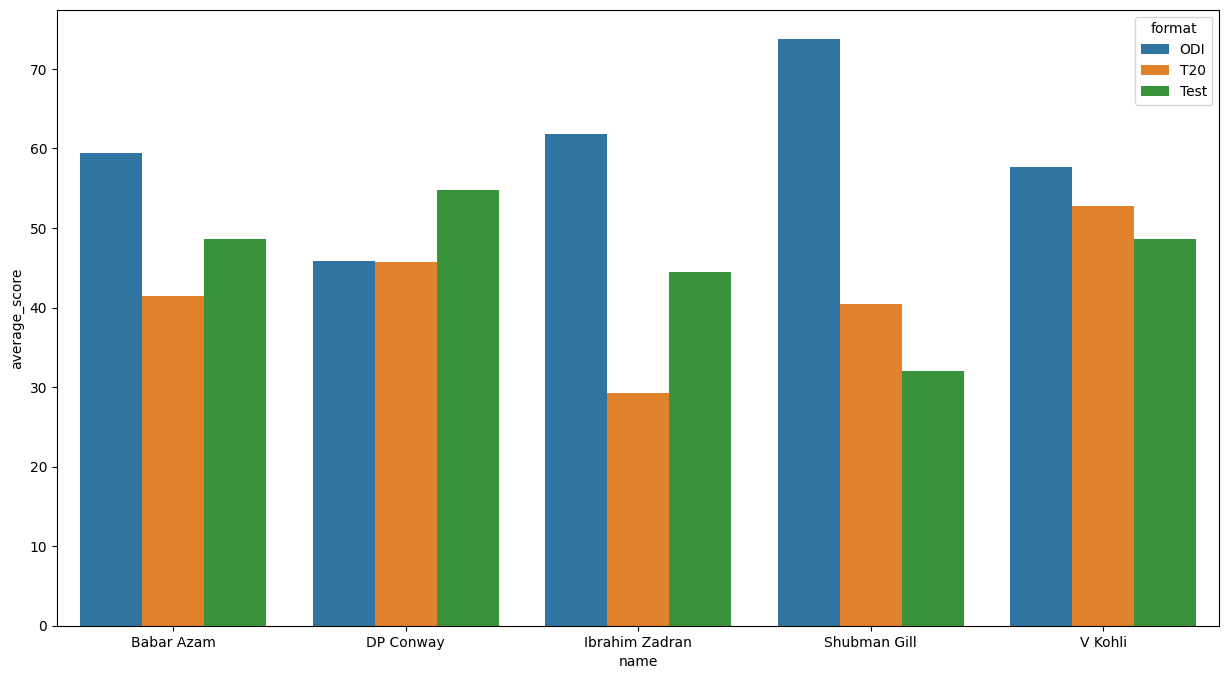

In [29]:
plt.subplots(figsize = ([15,8]))
top_batsmen = data.groupby('name')['average_score'].sum().nlargest(5).index.tolist()
top_batsmen_avg = data[data['name'].isin(top_batsmen)]
top_batsmen_avg = top_batsmen_avg.groupby(['name', 'format'])['average_score'].sum().reset_index()
sns.barplot(x='name', y='average_score', hue='format', data=top_batsmen_avg)
plt.show()

##### In the above plot , we can observer Gill is having maximum average in ODI , Conway in T20. Virat is having average of 50 in all three formats also he is having maximum average score in tests. Where as Babar and Zardan are also having good average in two formats

### Plotting innings wise runs scored in all three formats 

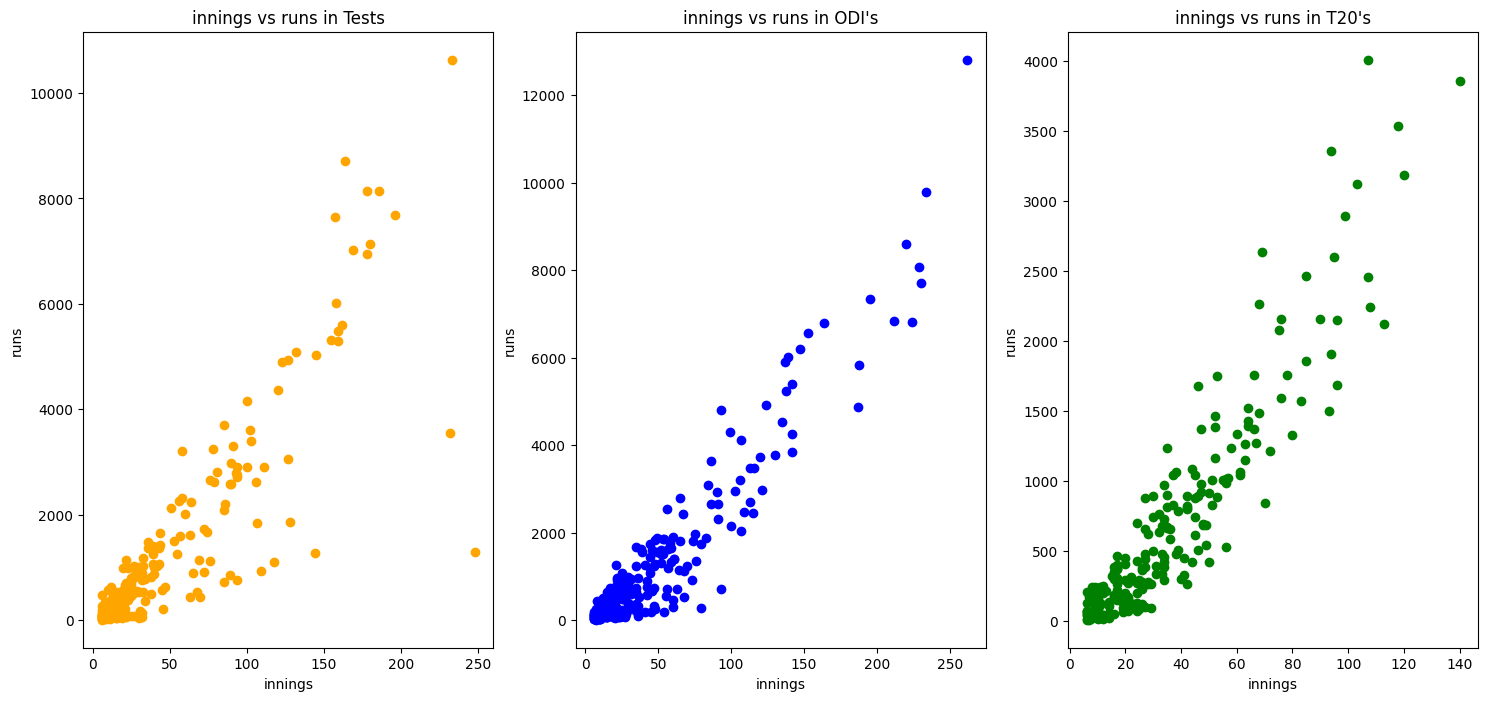

In [30]:
fig, (axis1, axis2, axis3) = plt.subplots(1, 3, figsize=(18, 8))
axis1.scatter(x='innings', y='runs', data=test_data , color = 'orange' )
axis1.set_title("innings vs runs in Tests")
axis2.scatter(x='innings', y='runs', data=odi_data,  color = 'blue' )
axis2.set_title("innings vs runs in ODI's")
axis3.scatter(x='innings', y='runs', data= t20_data, color = 'green')
axis3.set_title("innings vs runs in T20's")
axis1.set_xlabel('innings')
axis2.set_xlabel('innings')
axis3.set_xlabel('innings')
axis1.set_ylabel('runs')
axis2.set_ylabel('runs')
axis3.set_ylabel('runs')
plt.show()

##### from the above scatter plots, There are less than 5 people who has played more than 200 innings in tests out of them only one player has scored more than 1000 runs  and other player have scored less than 4000 runs .
##### Simillarly, There is only player who have played more than 250 innings and scored more than 12000 runs in ODI's.
##### In T20 , There is a player who have played maximum times and scored nearly 4000 runs. Also there is player who have scored most runs with100-110 innings

##### Alll these  players are having good chances to be awarded

### Plotting Box plots to identify the outliers across all three formats based on there batting style 

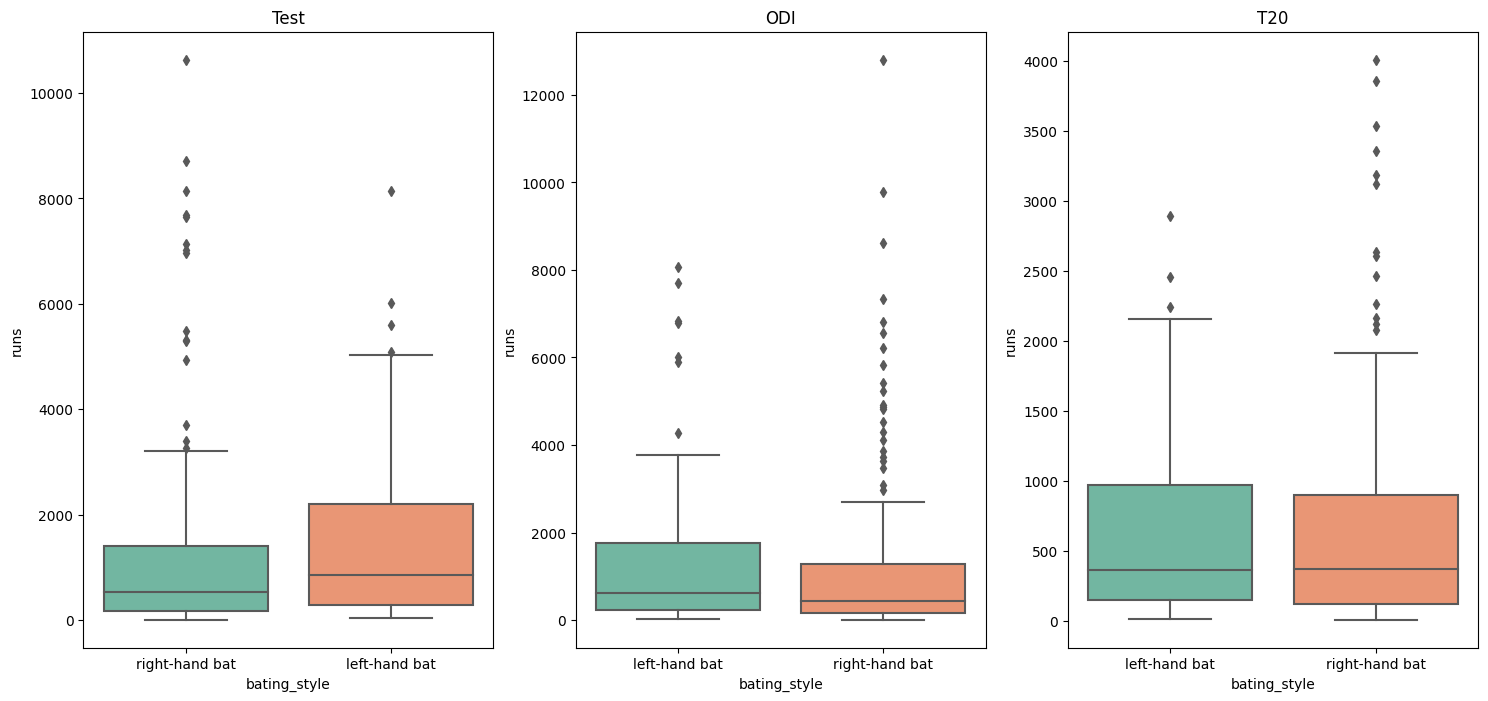

In [31]:
fig, (axis1, axis2, axis3) = plt.subplots(1, 3, figsize=(18, 8))
sns.boxplot(x =test_data['bating_style'], y = data['runs'], orient='v' , palette="Set2" , ax = axis1 ).set_title("Test")
sns.boxplot(x =odi_data['bating_style'], y = data['runs'], orient='v' , palette="Set2", ax = axis2).set_title("ODI")
sns.boxplot(x =t20_data['bating_style'], y = data['runs'], orient='v' , palette="Set2" , ax = axis3).set_title("T20")
plt.show()

##### From the above plots , Right handers are having maximum runs in all three formats where there are maximum left handers with median score

### Converting Categorical data into numerical  and adding into main DF (which could be used as a feature for analysis)

In [32]:
bating_style = pd.get_dummies(data["bating_style"])
format_data = pd.get_dummies(data['format'])
data = pd.concat([data , bating_style , format_data] , axis = 1)
remove_unwanted_columns(['bating_style','format'])

['bating_style', 'format'] removed from data frame


### Slicing all the featured columns from the data into a new data frame 

In [33]:
feature_columns = ['matches', 'innings',
       'not_out', 'runs',  'average_score', 'ball_faced',
       'strike_rate', 'centuries', 'half-century', 'duck_out', 'fours',
       'sixes', 'left-hand bat',
       'right-hand bat','ODI', 'T20', 'Test']
featured_data = data[feature_columns]
featured_data.head()

,matches,innings,not_out,runs,average_score,ball_faced,strike_rate,centuries,half-century,duck_out,fours,sixes,left-hand bat,right-hand bat,ODI,T20,Test
0,22,19,5,495,35.35,546.0,90.65,0,3,2,45,7,1,0,1,0,0
1,60,55,8,1003,21.34,832.0,120.55,0,3,6,72,33,1,0,0,1,0
2,5,10,0,100,10.00,260.0,38.46,0,0,1,14,0,0,1,0,0,1
3,44,41,0,1254,30.58,1691.0,74.15,3,5,6,122,27,0,1,1,0,0
4,20,20,2,445,24.72,395.0,112.65,0,1,1,46,14,0,1,0,1,0


### Plotting pair plot to identify relation between two features 

In [34]:
# sns.pairplot(data=featured_data)
# plt.show()

### plotting heat map to identify co-relation between two features 

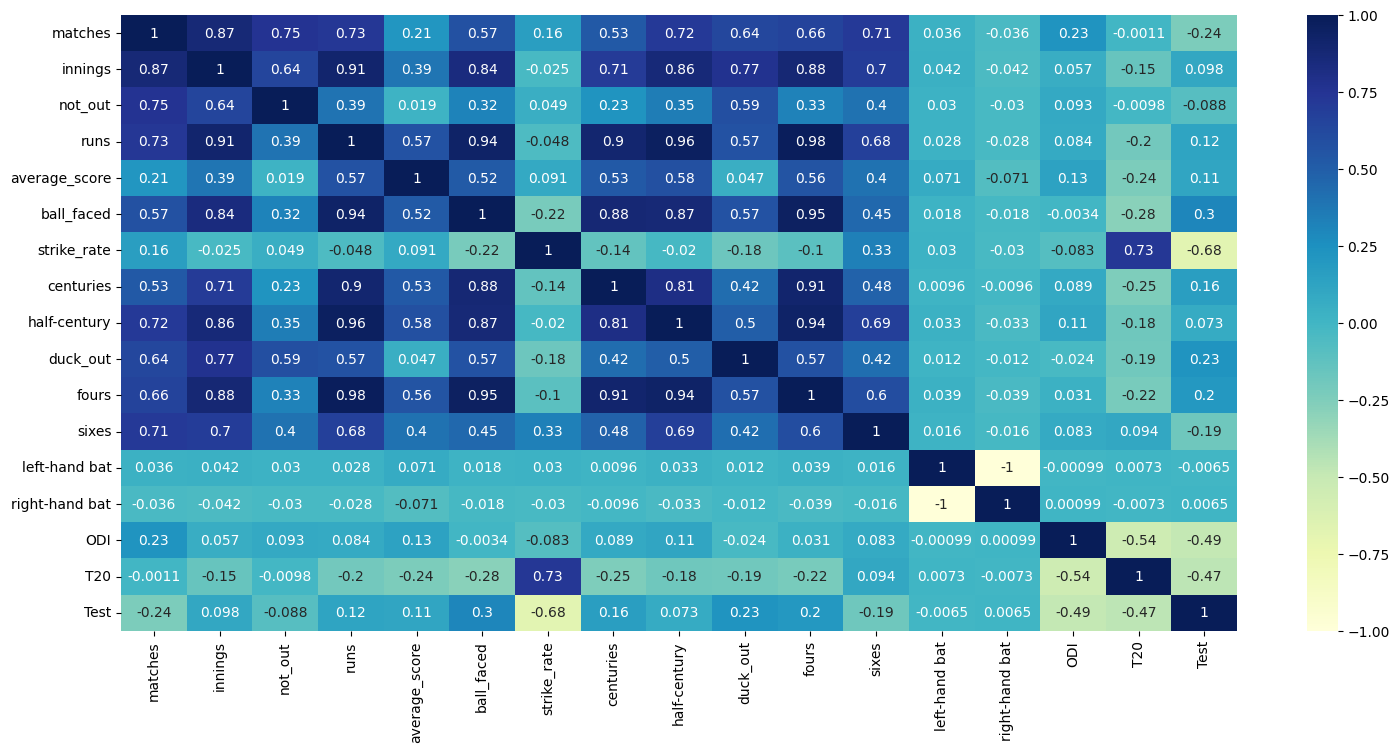

In [35]:
plt.subplots(figsize = ([18,8]))
sns.heatmap(data[feature_columns].corr(), annot=True, cmap="YlGnBu")
plt.show()

### Computing combined average score to identify average score of a player in all formats that he played 

In [36]:
combined_average_score = name_groups.average_score.sum()/name_groups.average_score.count()
combined_average_score = combined_average_score.to_frame()
combined_average_score.rename({"average_score" : "combined_average_score"} , axis =1 ,inplace = True)
combined_average_score.reset_index(inplace = True)
data = pd.merge(data, combined_average_score, on='name', how='inner')

### Categorizing players based on their average scores 

In [37]:
avg_bins = np.linspace(min(data["combined_average_score"]), max(data["combined_average_score"]), 5)
bin_names = ["In-consistent","Moderate" , "Consistent" , "Top-performer"]
data['Player-category'] = pd.cut(data['combined_average_score'], avg_bins, labels=bin_names, include_lowest=True )
data.head()

,name,gender,country_name,matches,innings,not_out,runs,average_score,ball_faced,strike_rate,...,duck_out,fours,sixes,left-hand bat,right-hand bat,ODI,T20,Test,combined_average_score,Player-category
0,Afif Hossain,Male,Bangladesh,22,19,5,495,35.35,546.0,90.65,...,2,45,7,1,0,1,0,0,28.345000,Moderate
1,Afif Hossain,Male,Bangladesh,60,55,8,1003,21.34,832.0,120.55,...,6,72,33,1,0,0,1,0,28.345000,Moderate
2,Anamul Haque,Male,Bangladesh,5,10,0,100,10.00,260.0,38.46,...,1,14,0,0,1,0,0,1,21.766667,Moderate
3,Anamul Haque,Male,Bangladesh,44,41,0,1254,30.58,1691.0,74.15,...,6,122,27,0,1,1,0,0,21.766667,Moderate
4,Anamul Haque,Male,Bangladesh,20,20,2,445,24.72,395.0,112.65,...,1,46,14,0,1,0,1,0,21.766667,Moderate


In [38]:
top_performers = data[data['Player-category'] == 'Top-performer']
top_performers.head()


,name,gender,country_name,matches,innings,not_out,runs,average_score,ball_faced,strike_rate,...,duck_out,fours,sixes,left-hand bat,right-hand bat,ODI,T20,Test,combined_average_score,Player-category
455,Saud Shakeel,Male,Pakistan,5,10,2,580,72.5,1392.0,41.66,...,0,72,1,1,0,0,0,1,72.5,Top-performer


In [39]:
top_performers = list(set(top_performers['name'].to_list()))

### Defining a method to compute and return a list with best strike rates in each format 

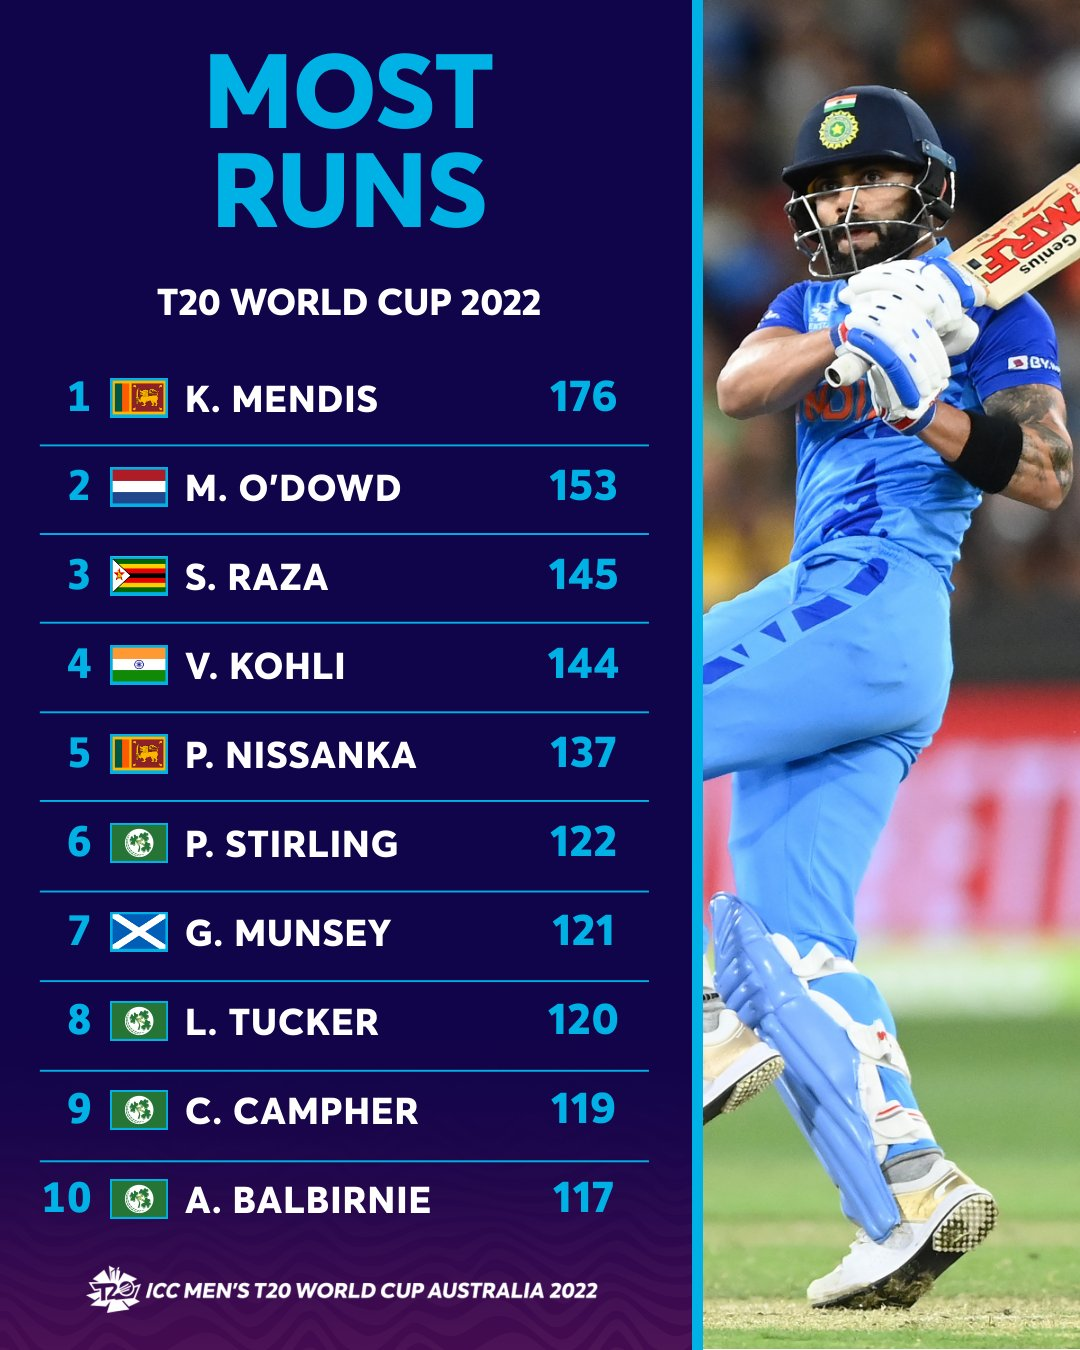

In [40]:
img = Image.open('most_runs.jpg_large')
img

In [41]:
imgarray = np.asarray(img)
imgarray.shape

(1350, 1080, 3)

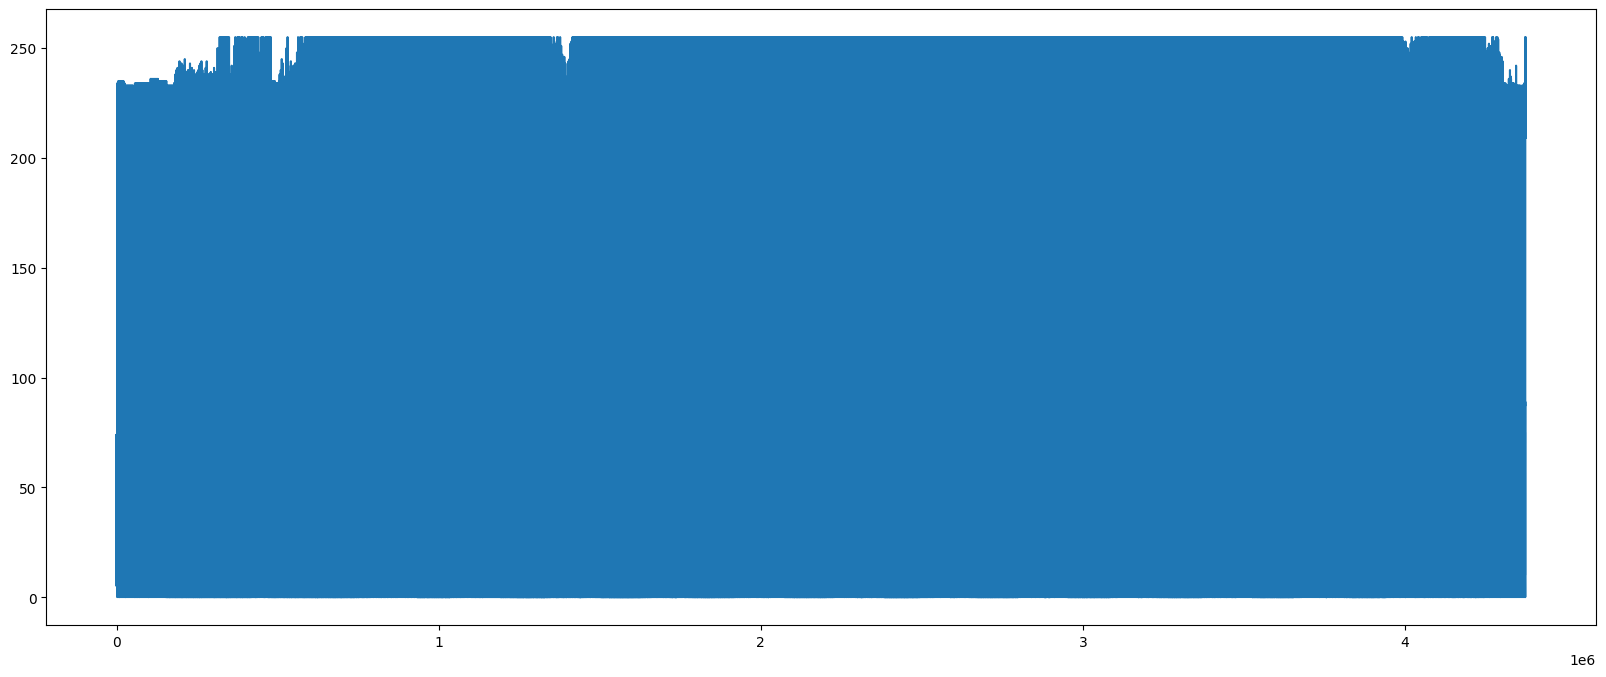

In [42]:
df = pd.DataFrame({'pixel_values': imgarray.flatten()})
plt.subplots(figsize = ([20,8]))
plt.plot(df)
plt.show()

In [43]:
sliced_image = imgarray[350:1250 , :550]

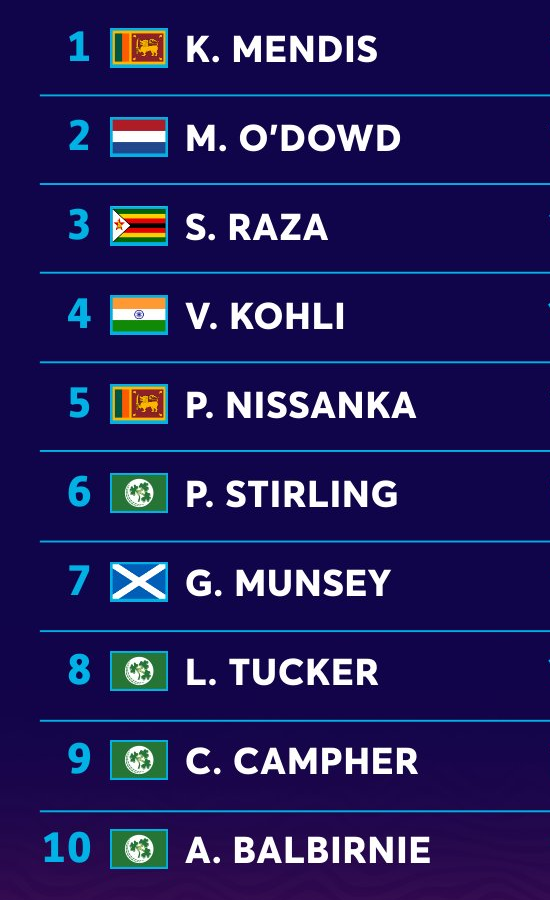

In [44]:
sliced_image = Image.fromarray(sliced_image)
sliced_image

In [45]:
sliced_image.save('top_runs.png')

In [46]:
with open('data.txt', 'r') as f:
    for line in f:
        print(line)

Ishan Kishan IND 498.0 t20

Hazratullah AFG 537.0 t20

Afif Hossain BAN 486.0 t20

Jos Buttler ENG 670.0 t20

Moeen Ali ENG 498.0 t20

Matthew Wade AUS 448.0 t20

Virat Kohli IND 612.0 t20

Babar Azam PAK 778.0 t20

Kane Williamson NZ 513.0 t20

Mitchell Marsh AUS 552.0 t20

Mohammad Rizwan PAK 836.0 t20

Daryl Mitchell NZ 552.0 t20

Rohit Sharma IND 545.0 t20

Glenn Maxwell AUS 527.0 t20

Rilee Rossouw SA 693.0 t20

David Miller SA 542.0 t20

Vriitya Aravind UAE 468.0 t20

Shan Masood PAK 469.0 t20

Lokesh Rahul IND 548.0 t20

Dawid Malan ENG 705.0 t20

"Max ODowd" NED 517.0 t20

Nicholas Pooran WI 582.0 t20

George Munsey SCO 572.0 t20

Iftikhar Ahmed PAK 478.0 t20

Rassie van der Dussen SA 565.0 t20

Martin Guptill NZ 547.0 t20

Richard Berrington SCO 558.0 t20

Aiden Markram SA 748.0 t20

Aaron Finch AUS 680.0 t20

Ben Duckett ENG 498.0 t20

Bhanuka Rajapaksa SL 517.0 t20

Hardik Pandya IND 484.0 t20

Nazmul Shanto BAN 593.0 t20

Glenn Phillips NZ 662.0 t20

Litton Das BAN 566.0 t2

In [47]:
data = []
columns = ["first_name"  , "last_name", "country"  ,"rating" , "format" ] 
with open('data.txt', 'r') as f:
    for line in f:
        fields = line.split()
        if len(fields) == 5:
            data.append(dict(zip(columns,fields)))
data = pd.DataFrame(data)         
data.head()

,first_name,last_name,country,rating,format
0,Ishan,Kishan,IND,498.0,t20
1,Afif,Hossain,BAN,486.0,t20
2,Jos,Buttler,ENG,670.0,t20
3,Moeen,Ali,ENG,498.0,t20
4,Matthew,Wade,AUS,448.0,t20


In [48]:
data = data.sort_values("rating" , ascending=False)
data = data.reset_index(drop = True)
data = data[['first_name' , 'last_name' , 'rating']].head()


In [49]:
data['rating']  =data['rating'].astype("float")
t20_top_players = data['first_name'] + " " + data['last_name']
t20_top_players = t20_top_players.to_list()

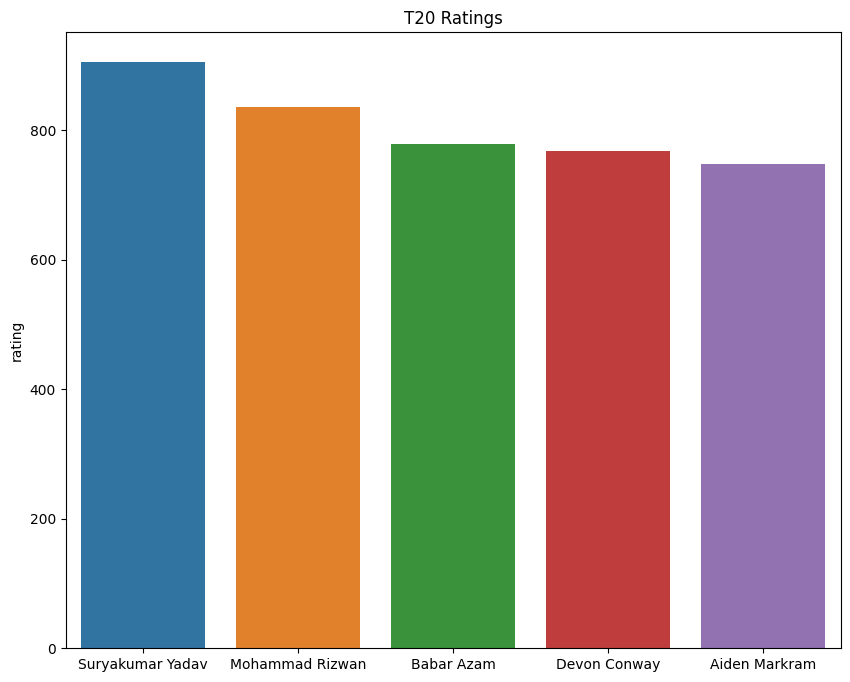

In [50]:
plt.subplots(figsize = ([10,8]))
sns.barplot(x = data['first_name']+" "+data['last_name'], y = data['rating']).set_title("T20 Ratings")
plt.show()

In [51]:
def identify_best_strike_rate(**kwargs):
    result = []
    for key, value in kwargs.items():
        result += value
    return set(result)

test =test_data.loc[test_data['strike_rate'].nlargest(3).index.to_list()].name.to_list()
odi =odi_data.loc[odi_data['strike_rate'].nlargest(3).index.to_list()].name.to_list()
t20 = t20_data.loc[t20_data['strike_rate'].nlargest(3).index.to_list()].name.to_list() 

### Defining a custom method which will accept lists ( player details based on various features) and return their occurance across all of them 

In [52]:
def fetch_final_list(*args):
    result = {}
    for i in args:
        for j in i :
            result[j] = result.get(j,0)+1
    return dict(sorted(result.items(), key=lambda item : item[1], reverse=True))


### defining a custom method to identify best n players from the result set 

In [53]:
def fetch_players(data , num ):
    try:
        if num < len(data):
            return [i[0] for i in itertools.islice(data.items(), num)]
        else:raise UserDefinedException(f"Data available for {len(data)-1} players only")
    except UserDefinedException as e:
        print(e)
    except Exception as e:
        print(f"Exception ocuured while fetching players  : {e}")



### Defining a data engg method which helps in taking data based on various features and return list of players based on their performances 

In [54]:
def data_engg():
    try:
        most_runs = player_runs['name'].to_list()
        most_centuries = player_centuries['name'].to_list()
        most_half_centuries = player_half_centuries['name'].to_list()
        most_average = set(top_batsmen_avg['name'].to_list())
        most_sixes = name_groups['sixes'].sum().nlargest(5).index.tolist()
        most_fours = name_groups['fours'].sum().nlargest(5).index.tolist()
        least_ducks  = name_groups['duck_out'].sum().nlargest(5).index.tolist()
        most_innings = (name_groups['innings'].sum().nlargest(5)).index.tolist()
        best_strike_rate = identify_best_strike_rate(test = test , odi = odi , t20 = t20)
        return fetch_final_list(most_runs , most_centuries, most_half_centuries, most_average,
                t20_top_players,   top_performers,  most_fours, most_innings, most_sixes, best_strike_rate,least_ducks)
        
    except Exception as e:
        print(f"Exception ocuured while fetching the required data : {e}")

   


##### In the above method , It computes and fetch best players by identifying the players from different categories like most runs,  most_centuries, most_half_centuries, most_average,best_boundary_ratio,  top_performers,  most_fours, most_active, most_innings, most_sixes, best_strike_rate,least_ducks

### Visualing top 10 contenders for the problem statement

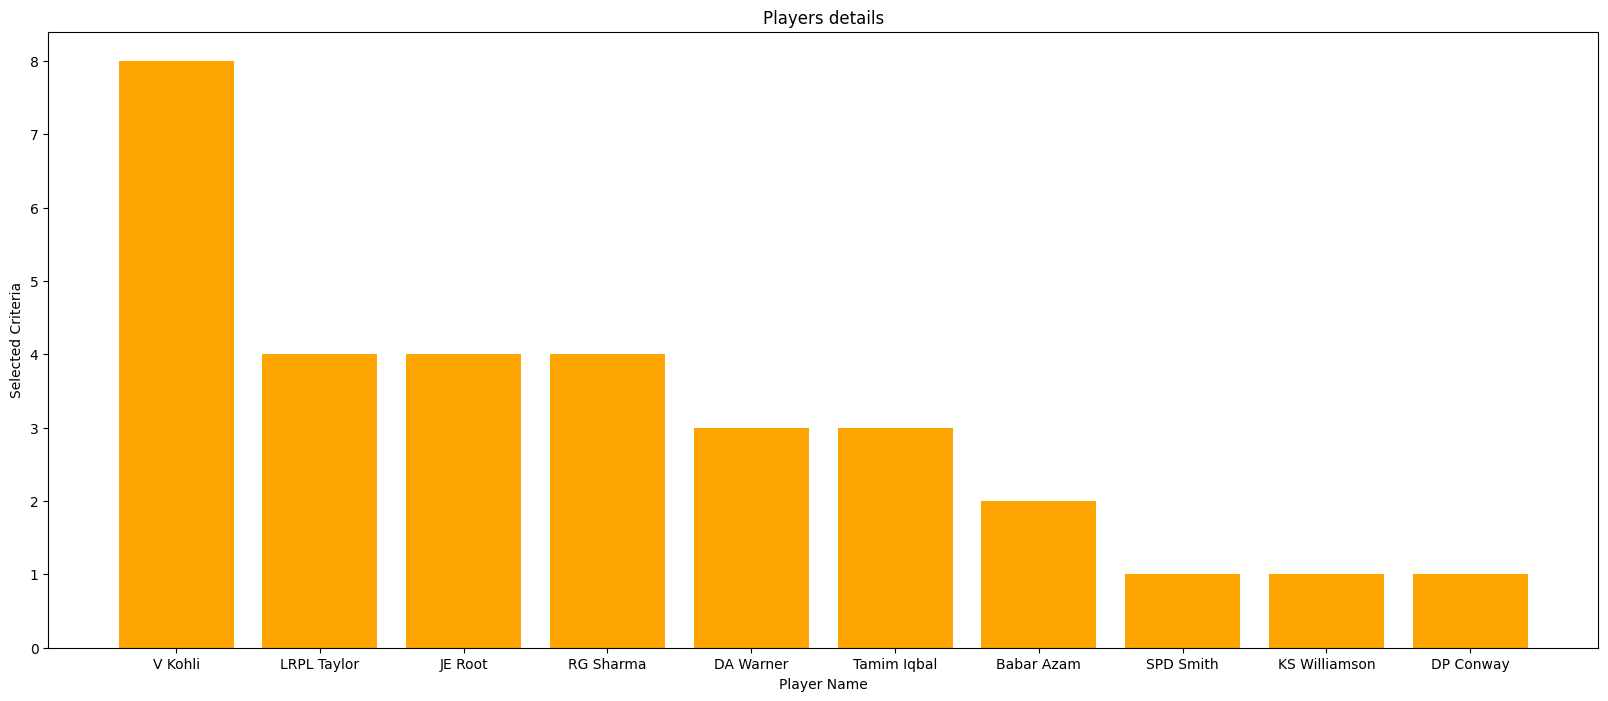

In [55]:
final_list = data_engg()

plt.subplots(figsize = ([20,8]))
labels = list(final_list.keys())
values = list(final_list.values())
plt.bar(labels[:10], values[:10] , color = 'orange')
plt.title('Players details')
plt.xlabel('Player Name')
plt.ylabel('Selected Criteria')
plt.show()



### Fetching required N players  

In [56]:
fetch_players(final_list,5)

['V Kohli', 'LRPL Taylor', 'JE Root', 'RG Sharma', 'DA Warner']

In [57]:
data.to_csv("cleaned_data.csv")

## Conclusion:

##### From the above analysis we have successfully identified the top 5 performing cricketers based on a range of performance metrics, including batting average, strike rate, total runs scored,  boundaries, innings played and years active. The final ranking was based on a weighted combination of batting, which were determined through exploratory data analysis.

##### The top 5 cricketers identified through the analysis were V Kohli, LRPL Taylor, JE Root, RG Sharma, and  DA Warner, who demonstrated consistent and exceptional performance in batting. These cricketers have the potential to serve as strong brand ambassadors for the company's products and can significantly enhance their brand image.

#### The limitations of the analysis included the availability and completeness of the data, as well as the potential for bias in the selection of performance metrics and the weighting scheme used. However, the analysis approach employed was robust and rigorous, taking into account a range of factors to arrive at the final ranking.

#### Overall, this analysis provides valuable insights and recommendations for the company to make informed decisions about its marketing strategy and product endorsement deals. The report serves as a valuable tool for future reference and can be used to inform future analyses or updates to the ranking criteria.